In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from IPython.display import Image,display
import time
from ipywidgets import interact

In [46]:
data = pd.read_csv('feature_target.csv')

In [47]:
x_train = list(data['Feature'])

In [48]:
y_train = list(data['Target'])

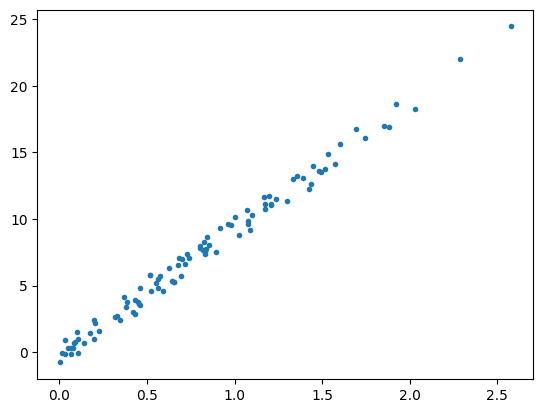

In [49]:
plt.plot(x_train,y_train,marker='.',linestyle='none')

In [50]:
def cost_function_loop(x_values,y_values,w,b):
    total_cost = 0
    for x_i,y_i in zip(x_values,y_values):
        total_cost += (w*x_i + b - y_i)**2
    return total_cost
def cost_function(x_values,y_values,w,b):
    mse = cost_function_loop(x_values,y_values,w,b)*(1/(2*len(x_values)))
    return mse

    #Vectorized version
    def cost_function_loop(x_values,y_values,w,b):
        result = np.square(temp_x * w + b - temp_y)
        return np.sum(result)
        
    temp_x = np.array(x_train)
    temp_y = np.array(y_train)

    start_time = time.time()
    cost_function(x_train,y_train,9.6,-.101)
    end_time = time.time()
    elapsed_time = end_time - start_time
    print(f"Elapsed time: {elapsed_time:.10f} seconds\n")

In [51]:
temp_data = pd.DataFrame(columns = ["W_values","B_values"])

In [52]:
temp_data["W_values"] = list(np.linspace(-10.0, 10.0, 1000))

In [53]:
temp_data["B_values"] = list(np.linspace(-10.0, 10.0, 1000))

In [54]:
costs = []

In [55]:
for w in temp_data["W_values"]:
    for b in temp_data["B_values"]:
        costs.append(cost_function(x_train,y_train,w,b))

In [56]:
min(costs)

0.15306445259110366

In [57]:
x_grid, y_grid = np.meshgrid(np.unique(temp_data["W_values"].values), np.unique(temp_data["B_values"].values))
z_grid = np.array(costs).reshape(x_grid.shape)

In [58]:
'''import plotly.graph_objects as go
fig = go.Figure(data=[go.Surface(x=x_grid, y=y_grid, z=z_grid)])
fig.update_layout(
    title='Cost Surface',
    autosize=True,
    scene=dict(
        xaxis_title='W_values',
        yaxis_title='B_values',
        zaxis_title='Cost_values'
    )
)
fig.show()'''

"import plotly.graph_objects as go\nfig = go.Figure(data=[go.Surface(x=x_grid, y=y_grid, z=z_grid)])\nfig.update_layout(\n    title='Cost Surface',\n    autosize=True,\n    scene=dict(\n        xaxis_title='W_values',\n        yaxis_title='B_values',\n        zaxis_title='Cost_values'\n    )\n)\nfig.show()"

In [59]:
#cost function derivatives
def cost_function_der_w_loop(x_values,y_values,w,b):
    total_cost = 0
    for x_i,y_i in zip(x_values,y_values):
        total_cost += (w*x_i + b - y_i)*x_i
    return total_cost

In [60]:
def cost_function_der_w(x_values,y_values,w,b):
    mse = cost_function_der_w_loop(x_values,y_values,w,b)*(1/(len(x_values)))
    return mse

In [61]:
def cost_function_der_b_loop(x_values,y_values,w,b):
    total_cost = 0
    for x_i,y_i in zip(x_values,y_values):
        total_cost += (w*x_i + b - y_i)
    return total_cost

In [62]:
def cost_function_der_b(x_values,y_values,w,b):
    mse = cost_function_der_b_loop(x_values,y_values,w,b)*(1/(len(x_values)))
    return mse

In [63]:
def gradient_descent(x_values,y_values,alpha,thresh,w= -100000,b = -100000):
    delta = 100
    steps = 0
    while(delta > thresh):
        temp_w = w - alpha*cost_function_der_w(x_values,y_values,w,b)
        temp_b = b - alpha*cost_function_der_b(x_values,y_values,w,b)
        delta = abs(cost_function(x_values,y_values,w,b) - cost_function(x_values,y_values,temp_w,temp_b))
        w = temp_w
        b = temp_b
        #print(delta,w,b)
        steps+=1
    print("Total Steps",steps)
    print(f"Final : w = {w},b = {b}")
    print(f"Final cost: {cost_function(x_values,y_values,w,b)}")
    return w,b

In [64]:
true_w , true_b = gradient_descent(x_train,y_train,0.01,0.000001)

Total Steps 5398
Final : w = 9.459901321172612,b = -0.16070093741641853
Final cost: 0.1533014572259237


In [65]:
cost_function(x_train,y_train,true_w , true_b)

0.1533014572259237

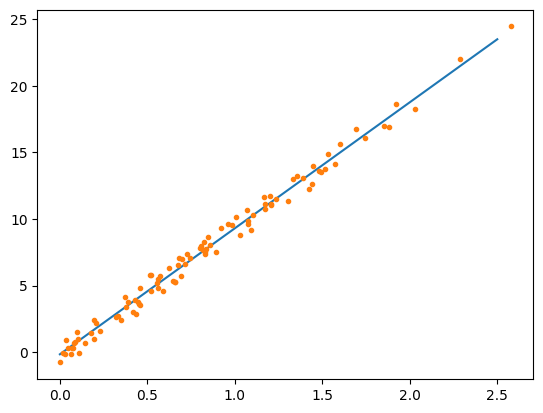

In [66]:
x = np.linspace(0, 2.5, 100)  # Generates 100 points between -5 and 5

# Calculate corresponding y values
y = true_w * x + true_b

# Plot the line
plt.plot(x, y)
plt.plot(x_train,y_train,marker='.',linestyle='none')

# Works well, I have a theory for a better learning tho in theory, heres a picture

# fuck the picture, heres the theory in coding, you want the image, its in my book

### First lets visualize the W curve so i can see what im working with by constanting (a word now mfer) b.

In [67]:
visualizing_w = []
for w in temp_data["W_values"]:
    visualizing_w.append(cost_function(x_train,y_train,w,-0.0732412035546501))

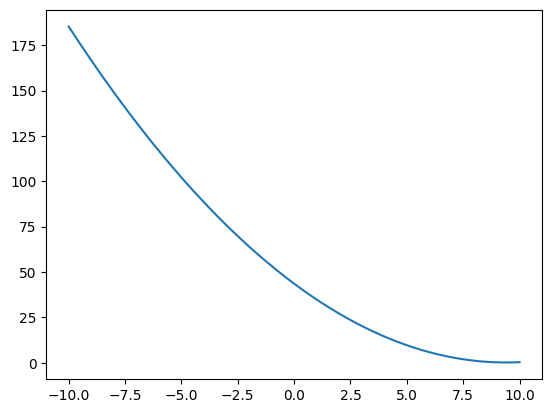

In [68]:
plt.plot(temp_data["W_values"],visualizing_w)

In [69]:
min(visualizing_w)

0.15564037819366577

In [70]:
cost_function_der_w(x_train,y_train,-10,1)

-18.211599557614367

In [71]:
cost_function_der_w(x_train,y_train,10,1)

1.4744172045673656

In [ ]:
#Image("ExampleForLooking.png")

FileNotFoundError: No such file or directory: 'ExampleForLooking.png'

FileNotFoundError: No such file or directory: 'ExampleForLooking.png'

<IPython.core.display.Image object>

In [73]:
def find_overstep_w(x_values,y_values,b = -0.16062904420006546):
    w = 1
    slope = cost_function_der_w(x_values,y_values,w,b)
    negative_w = w
    negative_slope = slope
    count = 0
    while(negative_slope*slope > 0):
        count+=1
        negative_w = negative_w - 1.2*cost_function_der_w(x_values,y_values,negative_w,b)    #overshoot the minimum
        negative_slope = cost_function_der_w(x_values,y_values,negative_w,b)
    print("Iterations: ", count)
    return w,slope,negative_w,negative_slope

In [74]:
find_overstep_w(x_train,y_train)

Iterations:  1


(1, -8.33411978051147, 11.000943736613763, 1.5098175213192764)

In [75]:
def calc_approx(x_1,cost_1,slope_1,x_2,cost_2,slope_2):
    top_2_term = abs(slope_2*cost_2)
    top_1_term = abs(slope_1*cost_1)
    return (x_1*top_2_term + x_2*top_1_term) / (top_2_term+top_1_term)

In [76]:
def newton_simma_descent(x_values,y_values,b = -0.16062904420006546):
    w,slope_w,neg_w,slope_neg_w = find_overstep_w(x_values,y_values)
    delta = 1
    guess = 0
    for i in range(0,1500):
        w_cost = cost_function(x_values,y_values,w,b)
        w_neg_cost = cost_function(x_values,y_values,neg_w,b)
        guess = calc_approx(w,w_cost,slope_w,neg_w,w_neg_cost,slope_neg_w)
        if (w_cost < w_neg_cost):
            w = guess
            slope_w = cost_function_der_w(x_values,y_values,w,b)
        else:
            neg_w = guess
            slope_neg_w = cost_function_der_w(x_values,y_values,neg_w,b)
        print("Cost :" , cost_function(x_values,y_values,guess, b) , "\nW value: ",guess)

In [77]:
newton_simma_descent(x_train,y_train)

Iterations:  1
Cost : 1.2128671655415755 
W value:  10.934349158970898
Cost : 1.1299547425464724 
W value:  10.875772007472433
Cost : 1.0590246545454303 
W value:  10.823654364516647
Cost : 0.9975909262512564 
W value:  10.776839564885984
Cost : 0.943821421521001 
W value:  10.734446896870065
Cost : 0.8963339136355312 
W value:  10.695791401907183
Cost : 0.8540645695130004 
W value:  10.660330655833919
Cost : 0.8161803563014836 
W value:  10.627628361020012
Cost : 0.7820190645974606 
W value:  10.597328779261902
Cost : 0.7510472420751941 
W value:  10.56913836550776
Cost : 0.7228300602084541 
W value:  10.542812309382494
Cost : 0.6970093223820473 
W value:  10.518144498180632
Cost : 0.6732871445003794 
W value:  10.494959913395933
Cost : 0.6514136628017917 
W value:  10.473108789334674
Cost : 0.6311776494563751 
W value:  10.45246206827369
Cost : 0.6123992599572112 
W value:  10.432907823554958
Cost : 0.594924365212242 
W value:  10.414348414872256
Cost : 0.5786200766443227 
W value:  

In [78]:
# Assuming the red line is the cost function across W, the 0.5 is the W that has a 

In [79]:
calc_approx(2,26,25,0.68227,10.42087,-1.3546)

0.7102789911954401

# Possibly promising? Gotta flush out the code tmrw

# Worth wasting my time and not learning more ML? probably not but I am stubborn and interested so 

### Gives us $w_{1}$ , $wslope_{1}$ , $negative w_{1}$ , $negative w slope_{1}$

In [80]:
def find_overstep_w(x_values,y_values,w=10000000000,b = 0):
    slope = cost_function_der_w(x_values,y_values,w,b)
    negative_w = w
    negative_slope = slope
    count = 0
    while(negative_slope*slope > 0):
        count+=1
        negative_w = negative_w - 1*count*cost_function_der_w(x_values,y_values,negative_w,b)
        negative_slope = cost_function_der_w(x_values,y_values,negative_w,b)
    #print("Iterations: ", count)
    return w,slope,negative_w,negative_slope

### Gives us $b_{1}$ , $bslope_{1}$ , $negative b_{1}$ , $negative b slope_{1}$

In [81]:
def find_overstep_b(x_values,y_values,b=1000000000000000,w = 0):
    slope = cost_function_der_b(x_values,y_values,w,b)
    negative_b = b
    negative_slope = slope
    count = 0
    while(negative_slope*slope > 0):
        count+=1
        negative_b = negative_b - 1*count*cost_function_der_b(x_values,y_values,w,negative_b)
        negative_slope = cost_function_der_b(x_values,y_values,w,negative_b)
    #print("Iterations: ", count)
    return b,slope,negative_b,negative_slope

### The special equation if you will, it weights $x_{1}$ and $x_{2}$ by the respective slopes and costs and gets the approximation of where the minimum should be, took a while to develop. Notice, it only needs 2 points to do this

In [82]:
def find_approx_min(x_1,cost_1,slope_1,x_2,cost_2,slope_2):
    top_2_term = abs(slope_2*cost_2)
    top_1_term = abs(slope_1*cost_1)
    #print((x_1*top_2_term + x_2*top_1_term) / (top_2_term+top_1_term))
    return (x_1*top_2_term + x_2*top_1_term) / (top_2_term+top_1_term)

# Two versions : One where this approximation is used to get better intial values for the normal gradient descent and one where this method gets to the end of the descent

## Version 1: Newton-Simma to provide a better starting point ---> Gradient descent

In [83]:
def better_init_gradient_descent(x_values,y_values,alpha,thresh,init_w,init_b):
    w,slope_w,neg_w,slope_neg_w = find_overstep_w(x_train,y_train,init_w,init_b)
    b,slope_b,neg_b,slope_neg_b = find_overstep_b(x_train,y_train,init_b,init_w)
    
    w_cost = cost_function(x_values,y_values,w,b)
    w_neg_cost = cost_function(x_values,y_values,neg_w,b)
    param_w = find_approx_min(w,w_cost,slope_w,neg_w,w_neg_cost,slope_neg_w)
    
    b_cost = cost_function(x_values,y_values,w,b)
    b_neg_cost = cost_function(x_values,y_values,w,neg_b)
    param_b = find_approx_min(b,b_cost,slope_b,neg_b,b_neg_cost,slope_neg_b)
    
    true_w , true_b = gradient_descent(x_values,y_values,alpha,thresh,param_w,param_b)
    return true_w , true_b

## Comparison of Newton-Simma approximation ---> Gradient Descent vs Normal Gradient Descent

In [84]:
for i in np.arange(-100, 100, 10):
    print("w,b Starting point: ",i,"\n")
    print("Newton-Simma method: ",better_init_gradient_descent(x_train,y_train,0.01,0.00000001,i,i))
    print()
    print("Normal Gradient method: ",gradient_descent(x_train,y_train,0.01,0.00000001,i,i))
    print()

w,b Starting point:  -100 

Total Steps 3420
Final : w = 9.49663190442502,b = -0.1970809025649841
Final cost: 0.15301768736588348
Newton-Simma method:  (np.float64(9.49663190442502), np.float64(-0.1970809025649841))

Total Steps 4131
Final : w = 9.496630891335322,b = -0.19707989914591234
Final cost: 0.15301768878928357
Normal Gradient method:  (np.float64(9.496630891335322), np.float64(-0.19707989914591234))

w,b Starting point:  -90 

Total Steps 3500
Final : w = 9.49663137935244,b = -0.1970803825045841
Final cost: 0.153017688103571
Newton-Simma method:  (np.float64(9.49663137935244), np.float64(-0.1970803825045841))

Total Steps 4126
Final : w = 9.49663213727074,b = -0.19708113318803885
Final cost: 0.15301768703878296
Normal Gradient method:  (np.float64(9.49663213727074), np.float64(-0.19708113318803885))

w,b Starting point:  -80 

Total Steps 3571
Final : w = 9.49663651155268,b = -0.1970854657145158
Final cost: 0.15301768089728307
Newton-Simma method:  (np.float64(9.49663651155268

### Final notes for version 1: You can see for a good amount of inputs, it beats the gradient descent but again, it doesnt for other values. To sum it up, its unreliable when looking at when its better and based on the inital starting values. But the fact that it beats it for the majority of inputs is promising, moving on to the next version, using it to approximate to the end

# Version 2 : Newton-Simma method to completion

In [85]:
def newton_simma_inner_loop(x_values,y_values,thresh,init_w,init_b):
    #print("Newton-simma Called:",init_w,init_b)
    w,slope_w,neg_w,slope_neg_w = find_overstep_w(x_train,y_train,init_w,init_b)
    b,slope_b,neg_b,slope_neg_b = find_overstep_b(x_train,y_train,init_b,init_w)
    #print("W",w,"Slope of W: ",slope_w,"Neg W: ",neg_w,"Slope of Neg W: ",slope_neg_w,"\n")
    #print("B",b,"Slope of B: ",slope_b,"Neg B: ",neg_b,"Slope of Neg B: ",slope_neg_b,"\n")

    
    w_cost = cost_function(x_values,y_values,w,b)
    w_neg_cost = cost_function(x_values,y_values,neg_w,b)
    param_w = find_approx_min(w,w_cost,slope_w,neg_w,w_neg_cost,slope_neg_w)
    
    b_cost = cost_function(x_values,y_values,w,b)
    b_neg_cost = cost_function(x_values,y_values,w,neg_b)
    param_b = find_approx_min(b,b_cost,slope_b,neg_b,b_neg_cost,slope_neg_b)

    return param_w , param_b

In [86]:
# Dont really have a clear idea on how to write it , something along these lines , do the same as before 
# to get the to initital values then introduce a delta variable to keep track of delta then which ever has a lower
# cost betweem the 2 positive and negative slopes gets reassigned indefinitely.

In [87]:
def newton_simma(x_values,y_values,thresh,w = 0,b = 0):
    delta = 100000000
    steps = 0
    while(delta > thresh):
        temp_w,temp_b = newton_simma_inner_loop(x_values,y_values,thresh,w,b)
        delta = abs(cost_function(x_values,y_values,w,b) - cost_function(x_values,y_values,temp_w,temp_b))
        w = temp_w
        b = temp_b
        steps+=1
    print(f"Total Steps: {steps}\nFinal w: {w}, b: {b}\nFinal Cost: {cost_function(x_values,y_values,w,b)}")
    return w,b

In [88]:
start_time = time.time()
true_w , true_b = newton_simma(x_train,y_train,thresh = 0.000000000001,w = 10000000000,b = 10000000000)
end_time = time.time()
elapsed_time = end_time - start_time
print(f"Elapsed time: {elapsed_time:.4f} seconds")

Total Steps: 202
Final w: 9.50071469436203, b: -0.20112264494515086
Final Cost: 0.1530148202797179
Elapsed time: 0.0419 seconds


In [89]:
start_time = time.time()
true_w , true_b = gradient_descent(x_train,y_train,alpha = 0.01,thresh = 0.000000000001,w = 10000000000,b = 10000000000)
end_time = time.time()
elapsed_time = end_time - start_time
print(f"Elapsed time: {elapsed_time:.4f} seconds")

Total Steps 15986
Final : w = 9.500754427819766,b = -0.20116407370317183
Final cost: 0.15301482056392068
Elapsed time: 0.6954 seconds


## Final Notes: Worked way better than I thought, might actually be useful. I understand that I am not up to date with the latest research in gradient descent but given what i do know, this seems to outpreform the benchmark pretty well.

# Dont believe me? Try it yourself! Why take the word of a kid on the internet

In [90]:
## This represents the starting value for w
starting_w = -1000

# This represents the starting value for b
starting_b = -1000 

# This represents the threshold that cost has to change between steps to trigger the stop
# Common values = 0.0001, 0.01, 0.0000000000001
thresh = 0.00000000000000000001

# alpha (learning rate) for the traditional gradient descent methods, common values = 0.01, 0.1, 0.001
alpha = 0.1

start_time = time.time()
true_w , true_b = newton_simma(x_train,y_train,thresh = thresh,w = starting_w,b = starting_b)
end_time = time.time()
elapsed_time = end_time - start_time
print("Newton-Simma method: ")
print(f"Elapsed time: {elapsed_time:.4f} seconds\n")

print("Gradient Descent method: ")
start_time = time.time()
true_w , true_b = gradient_descent(x_train,y_train,alpha = alpha,thresh = thresh,w = starting_w,b = starting_b)
end_time = time.time()
elapsed_time = end_time - start_time
print(f"Elapsed time: {elapsed_time:.4f} seconds")

Total Steps: 139
Final w: 9.500713653656863, b: -0.20112367909934936
Final Cost: 0.1530148202777511
Newton-Simma method: 
Elapsed time: 0.0267 seconds

Gradient Descent method: 
Total Steps 1037
Final : w = 9.500713524563762,b = -0.2011235608962411
Final cost: 0.15301482027775376
Elapsed time: 0.0410 seconds
